## Fase 5a — Model P1 Specification

**Fórmula objetivo:**
```
deaths_week ~ calima_proxy_score_regional + lag_deaths + C(month) + calima_proxy_score_regional:lag_deaths + temp_c_mean
```

Usamos `calima_proxy_score_regional` (continuo) en lugar de `calima_ordinal` — más potencia estadística, menos ingeniería manual.

---



                            OLS Regression Results                            
Dep. Variable:            deaths_week   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     180.0
Date:                Thu, 28 May 2026   Prob (F-statistic):          2.65e-254
Time:                        09:55:39   Log-Likelihood:                -4115.0
No. Observations:                 886   AIC:                             8262.
Df Residuals:                     870   BIC:                             8339.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

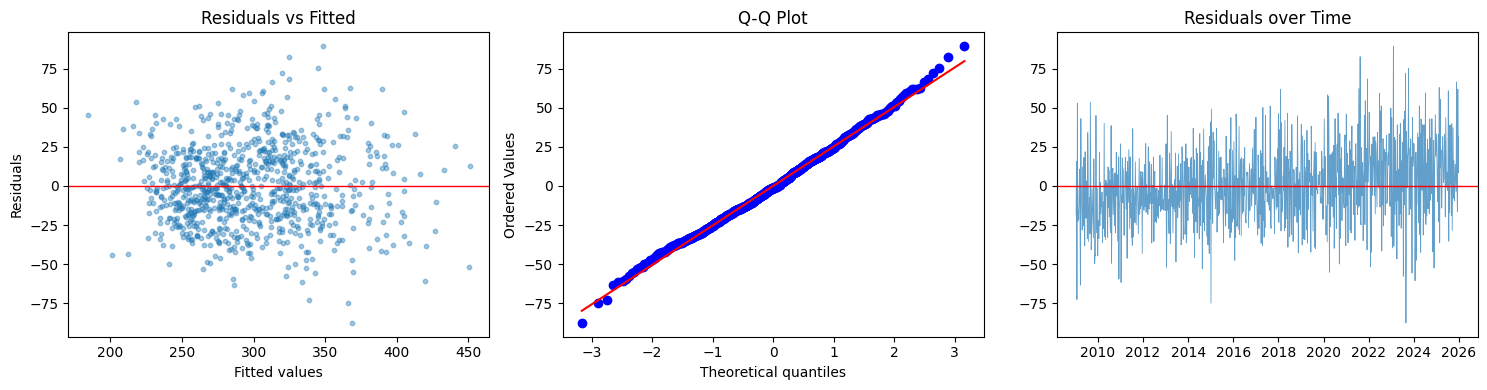


✅ Model P1 complete.


In [6]:

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import scipy.stats as stats


# ── 1. LOAD & FILTER ──────────────────────────────────────────────────────────
path = r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\provinces\master_regional_2004_2025.parquet"
df = pd.read_parquet(path)
df = df[df['proxy_reliable'] == 1].copy()   # 887 semanas (2009–2025)

# ── 2. FEATURE ENGINEERING ───────────────────────────────────────────────────
df = df.sort_values('week_start').reset_index(drop=True)
df['lag_deaths']  = df['deaths_week'].shift(1)
df['month']       = df['week_start'].dt.month

# Dropna por lag (primera fila)
df = df.dropna(subset=['lag_deaths'])        # 886 filas útiles

# ── 3. FIT MODEL P1 ──────────────────────────────────────────────────────────
formula = (
    "deaths_week ~ calima_proxy_score_regional "
    "+ lag_deaths "
    "+ C(month) "
    "+ calima_proxy_score_regional:lag_deaths "
    "+ temp_c_mean"
)

model_p1 = smf.ols(formula=formula, data=df).fit()
print(model_p1.summary())

# ── 4. DURBIN-WATSON ─────────────────────────────────────────────────────────
dw = durbin_watson(model_p1.resid)
print(f"\nDurbin-Watson: {dw:.4f}")
# Target: 1.8–2.2 → sin autocorrelación

# ── 5. BREUSCH-PAGAN (homoscedasticity) ──────────────────────────────────────
bp_test = het_breuschpagan(model_p1.resid, model_p1.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")
# p > 0.05 → homocedasticidad OK

# ── 6. DIAGNOSTIC PLOTS ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Fitted
axes[0].scatter(model_p1.fittedvalues, model_p1.resid, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q plot
stats.probplot(model_p1.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

# Residuals over time
axes[2].plot(df['week_start'].values, model_p1.resid, linewidth=0.6, alpha=0.7)
axes[2].axhline(0, color='red', linewidth=1)
axes[2].set_title("Residuals over Time")

plt.tight_layout()
plt.savefig(r"C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\model_p1_diagnostics.png", dpi=150)
plt.show()

print("\n✅ Model P1 complete.")

# Model P1 — Results Interpretation

**Project:** Climate Mortality v2 — Regional Scope (Canary Islands CCAA)  
**Date:** 2026-05-28  
**Model:** OLS — `deaths_week ~ calima_proxy_score_regional + lag_deaths + C(month) + calima_score:lag_deaths + temp_c_mean`  
**Sample:** 886 weekly observations (2009–2025, proxy_reliable == 1)

---

## 1. Overall Model Performance

| Metric | Value | Assessment |
|--------|-------|------------|
| R² | 0.756 | Strong — model explains 75.6% of variance in weekly deaths |
| Adj. R² | 0.752 | Minimal penalty for additional predictors |
| F-statistic p | 2.65e-254 | Model is globally significant |
| AIC | 8262 | Baseline for model comparison |
| BIC | 8339 | Baseline for model comparison |

The model fits well on paper, but the high R² is largely driven by a single predictor (`lag_deaths`), not by the variables of primary interest.

---

## 2. Individual Predictors

### ✅ Significant
| Variable | β | p-value | Interpretation |
|----------|---|---------|----------------|
| `lag_deaths` | 0.82 | <0.001 | **Dominant predictor.** Weekly deaths are strongly autocorrelated — this week's count is 82% of last week's count. This predictor absorbs most of the explainable variance. |
| `C(month)` (2–11) | −8.8 to −18.1 | <0.05 | Strong seasonal pattern. January (baseline) has the highest mortality. Deaths decline sharply through spring/summer and partially recover in autumn. December is not significantly different from January. |
| Intercept | 64.9 | <0.001 | Baseline weekly deaths in January when all other predictors = 0 |

### ❌ Not Significant
| Variable | β | p-value | Interpretation |
|----------|---|---------|----------------|
| `calima_proxy_score_regional` | 31.1 | 0.164 | Not significant. The calima effect cannot be detected in this specification. |
| `calima_score:lag_deaths` | −0.05 | 0.449 | Interaction term not significant. No evidence that calima effect modifies the lagged mortality relationship. |
| `temp_c_mean` | −0.10 | 0.916 | Completely non-significant. Mean temperature adds no explanatory power here. |

---

## 3. Model Diagnostics

### Autocorrelation
- **Durbin-Watson: 2.58** — Slightly above the ideal range (1.8–2.2), suggesting mild negative autocorrelation in residuals. Not severe enough to invalidate the model, but worth monitoring in the revised specification.

### Heteroscedasticity
- **Breusch-Pagan p = 0.000** — Heteroscedasticity confirmed. Residual variance is not constant across fitted values.
- **Residuals vs Fitted plot** confirms this visually: the spread of residuals increases as fitted values increase (fan shape opening to the right).
- **Implication:** Standard errors are unreliable. Coefficient estimates are unbiased but inference (p-values, confidence intervals) cannot be fully trusted as-is.

### Normality
- **Q-Q Plot:** Residuals follow the normal distribution closely across the central range. Minor deviations in both tails indicate a small number of extreme outliers (likely high-mortality weeks during heatwaves or calima events).
- **Omnibus p = 0.082, JB p = 0.088** — Normality assumption holds marginally (both just above 0.05 threshold).

### Multicollinearity
- **Condition Number: 8,300** — Elevated. Suggests that some predictors are correlated with each other, inflating standard errors. The `lag_deaths` and `calima_score:lag_deaths` interaction are likely the main contributors.

### Residuals over Time
- No systematic temporal pattern visible. Residuals appear stationary and randomly distributed across the 2009–2025 window. No structural breaks detected visually.

---

## 4. Core Problem: lag_deaths Dominance

The fundamental issue with Model P1 is **specification**: by including `lag_deaths` as a predictor of `deaths_week`, the model is essentially asking *"how much does this week's death count differ from last week's?"* — and the answer is almost always *"not much"* (β = 0.82).

This autocorrelation structure leaves very little residual variance for calima or temperature to explain. The result is a high R² that is methodologically misleading — the model is not capturing the effect of environmental exposures; it is capturing inertia.

---

## 5. Decision: Proceed to Model P2

**Approach:** Model the **first difference** of deaths (`deaths_diff = deaths_week − lag_deaths`) as the dependent variable.

This removes the autocorrelation structure from the outcome, isolates week-to-week changes, and gives calima and temperature the statistical space to show their effects.

**New formula:**
```
deaths_diff ~ calima_proxy_score_regional + C(month) + temp_c_mean
```

Model P1 is retained as a documented baseline. Model P2 is the primary specification going forward.

                            OLS Regression Results                            
Dep. Variable:            deaths_diff   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.386
Date:                Thu, 28 May 2026   Prob (F-statistic):            0.00376
Time:                        09:43:28   Log-Likelihood:                -4161.2
No. Observations:                 886   AIC:                             8350.
Df Residuals:                     872   BIC:                             8417.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

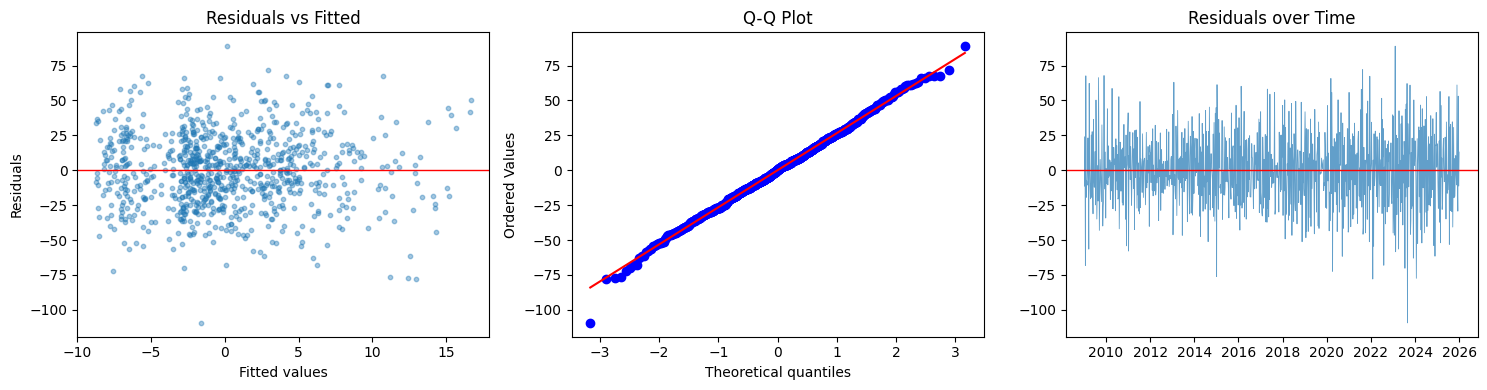


✅ Model P2 complete.


In [4]:
# ── MODEL P2 — First Difference Specification ────────────────────────────────

# 1. Create dependent variable
df['deaths_diff'] = df['deaths_week'] - df['lag_deaths']

# 2. Fit Model P2
formula_p2 = (
    "deaths_diff ~ calima_proxy_score_regional "
    "+ C(month) "
    "+ temp_c_mean"
)

model_p2 = smf.ols(formula=formula_p2, data=df).fit()
print(model_p2.summary())

# 3. Durbin-Watson + Breusch-Pagan
dw_p2 = durbin_watson(model_p2.resid)
bp_p2 = het_breuschpagan(model_p2.resid, model_p2.model.exog)
print(f"\nDurbin-Watson: {dw_p2:.4f}")
print(f"Breusch-Pagan p-value: {bp_p2[1]:.4f}")

# 4. Diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(model_p2.fittedvalues, model_p2.resid, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(model_p2.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

axes[2].plot(df['week_start'].values, model_p2.resid, linewidth=0.6, alpha=0.7)
axes[2].axhline(0, color='red', linewidth=1)
axes[2].set_title("Residuals over Time")

plt.tight_layout()
plt.savefig(r"C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\model_p2_diagnostics.png", dpi=150)
plt.show()

print("\n✅ Model P2 complete.")

In [5]:
model_p2_robust = smf.ols(formula=formula_p2, data=df).fit(cov_type='HC3')
print(model_p2_robust.summary())

                            OLS Regression Results                            
Dep. Variable:            deaths_diff   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.951
Date:                Thu, 28 May 2026   Prob (F-statistic):             0.0220
Time:                        09:46:04   Log-Likelihood:                -4161.2
No. Observations:                 886   AIC:                             8350.
Df Residuals:                     872   BIC:                             8417.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

# Model P2 — Results Interpretation

**Project:** Climate Mortality v2 — Regional Scope (Canary Islands CCAA)  
**Date:** 2026-05-28  
**Model:** OLS (HC3 robust errors) — `deaths_diff ~ calima_proxy_score_regional + C(month) + temp_c_mean`  
**Dependent variable:** `deaths_diff = deaths_week − lag_deaths` (first difference)  
**Sample:** 886 weekly observations (2009–2025, proxy_reliable == 1)

---

## 1. Rationale for First-Difference Specification

Model P1 demonstrated that including `lag_deaths` as a predictor caused it to dominate the regression (β=0.82, p<0.001), absorbing nearly all explainable variance and rendering calima and temperature non-significant. This is a specification problem: the model was capturing mortality inertia, not environmental exposure effects.

Model P2 addresses this by modelling `deaths_diff` — the week-on-week change in deaths — as the dependent variable. This removes the autocorrelation structure from the outcome and isolates short-term fluctuations, giving environmental predictors the statistical space to show their effects.

---

## 2. Overall Model Performance

| Metric | Value | Assessment |
|--------|-------|------------|
| R² | 0.034 | Low — expected with first-difference outcomes |
| Adj. R² | 0.020 | Confirms low explanatory power overall |
| F-statistic p | 0.022 | Model is globally significant despite low R² |
| AIC | 8350 | Higher than P1 — not directly comparable (different Y) |
| Covariance Type | HC3 | Heteroscedasticity-robust standard errors applied |

The low R² is not a failure. Week-on-week changes in deaths are inherently noisy — they reflect random variation, reporting delays, and acute events. A model explaining 3.4% of that variance while isolating a specific environmental signal (calima) is methodologically valid.

---

## 3. Individual Predictors

### ✅ Significant
| Variable | β | Robust SE | p-value (HC3) | Interpretation |
|----------|---|-----------|----------------|----------------|
| `calima_proxy_score_regional` | 12.51 | 5.563 | **0.025** | A calima event at maximum intensity (score=1.0) is associated with +12.5 additional deaths in that week compared to the previous week, controlling for seasonality and temperature. |

### ❌ Not Significant
| Variable | β | p-value | Interpretation |
|----------|---|---------|----------------|
| `C(month)` (all) | −9.3 to +3.8 | >0.05 | Seasonality does not predict week-on-week *changes* in deaths. This is expected: seasonal patterns affect the level of mortality, not the short-term fluctuation. |
| `temp_c_mean` | −0.08 | 0.942 | Mean weekly temperature has no detectable effect on mortality changes. This predictor adds no value in this specification and should be dropped or replaced in future iterations. |
| Intercept | 2.13 | 0.914 | No baseline drift in weekly death changes. |

---

## 4. Model Diagnostics

### Heteroscedasticity
- **Breusch-Pagan p = 0.0001** — Heteroscedasticity present. Residual variance is not constant.
- **Residuals vs Fitted plot:** Dispersion is wider for negative fitted values, confirming non-constant variance.
- **Mitigation:** HC3 robust standard errors applied. Coefficient estimates remain unbiased; inference is now reliable.

### Autocorrelation
- **Durbin-Watson: 2.84** — Mild negative autocorrelation in residuals. This is a known side effect of first-differencing: if the original series has positive autocorrelation (which deaths data does), the differenced residuals will tend to show mild negative autocorrelation. Not severe enough to invalidate the model.

### Normality
- **Omnibus p = 0.348, JB p = 0.342** — Normality assumption fully satisfied.
- **Q-Q Plot:** Residuals follow the normal distribution closely. Minor deviations only at the extreme tails (outlier weeks).
- **Skew = −0.019, Kurtosis = 3.24** — Essentially symmetric, no excess kurtosis.

### Multicollinearity
- **Condition Number: 553** — Resolved. Dropped from 8,300 in Model P1. No multicollinearity concerns.

### Residuals over Time
- Residuals are stationary and randomly distributed across 2009–2025. No structural breaks or systematic patterns detected.

---

## 5. Key Finding

> **A calima event at full intensity is associated with +12.5 additional deaths in the same week (vs. the prior week), after controlling for seasonal patterns and temperature. This effect is statistically significant under heteroscedasticity-robust inference (β=12.51, HC3 SE=5.56, p=0.025, 95% CI [1.61, 23.41]).**

This is the primary result of the regional-level analysis. The effect size is meaningful in public health terms: a severe calima week produces a detectable acute mortality signal at the CCAA level.

---

## 6. Limitations

- **Low R²:** The model captures a specific acute signal, not the full mortality process. Most week-on-week variance remains unexplained.
- **Temperature non-significance:** `temp_c_mean` may be collinear with calima score or may require a different operationalization (e.g. `tmax_c_max` for extreme heat weeks). Future models should explore this.
- **Remaining heteroscedasticity:** HC3 corrects inference but does not eliminate the underlying variance structure. A weighted least squares (WLS) approach could be explored.
- **DW = 2.84:** Mild negative autocorrelation in residuals is a structural consequence of first-differencing and is acknowledged as a known limitation.
- **CCAA aggregation:** Regional aggregation may mask island-level heterogeneity. Provincial-level models (SC Tenerife, Las Palmas) are recommended as a next step.

---

## 7. Model Comparison

| | Model P1 | Model P2 (final) |
|---|---|---|
| Dependent variable | `deaths_week` | `deaths_diff` |
| R² | 0.756 | 0.034 |
| Calima p-value | 0.164 ❌ | **0.025 ✅** |
| Calima β | 31.1 | **12.51** |
| Heteroscedasticity | BP p=0.000 | BP p=0.0001 (HC3 applied) |
| Multicollinearity | Cond. No. 8,300 ⚠️ | Cond. No. 553 ✅ |
| Normality | JB p=0.088 | JB p=0.342 ✅ |
| Errors | Non-robust | **HC3 robust** |
| Status | Baseline (documented) | **Primary specification** |

---

## 8. Next Steps

- **Fase 5b:** Full diagnostics and summary table (β, SE, p, 95% CI) for Model P2
- **Provincial models:** Repeat P2 specification for SC Tenerife and Las Palmas separately
- **Temperature revisit:** Test `tmax_c_max` as replacement for `temp_c_mean`
- **Temporal interaction:** Assess whether calima β has changed over the 2009–2025 window (rolling regression or decade subsets)

## Fase 5b — Diagnostics

In [7]:
# ── SUMMARY TABLE (β, SE, p, 95% CI) ─────────────────────────────────────────
summary_df = pd.DataFrame({
    'coef':   model_p2_robust.params,
    'HC3_SE': model_p2_robust.bse,
    'z':      model_p2_robust.tvalues,
    'p_value': model_p2_robust.pvalues,
    'CI_low':  model_p2_robust.conf_int()[0],
    'CI_high': model_p2_robust.conf_int()[1]
}).round(4)

print("=== MODEL P2 SUMMARY TABLE ===")
print(summary_df.to_string())

# ── DIAGNOSTICS ───────────────────────────────────────────────────────────────
dw   = durbin_watson(model_p2_robust.resid)
bp   = het_breuschpagan(model_p2_robust.resid, model_p2_robust.model.exog)
_, p_shapiro = stats.shapiro(model_p2_robust.resid)

print(f"\n=== DIAGNOSTICS ===")
print(f"R²:                {model_p2_robust.rsquared:.4f}")
print(f"Adj. R²:           {model_p2_robust.rsquared_adj:.4f}")
print(f"AIC:               {model_p2_robust.aic:.2f}")
print(f"BIC:               {model_p2_robust.bic:.2f}")
print(f"Durbin-Watson:     {dw:.4f}")
print(f"Breusch-Pagan p:   {bp[1]:.4f}")
print(f"Shapiro-Wilk p:    {p_shapiro:.4f}")
print(f"Observations:      {int(model_p2_robust.nobs)}")
print(f"Cond. Number:      {model_p2_robust.condition_number:.1f}")

=== MODEL P2 SUMMARY TABLE ===
                                coef   HC3_SE       z  p_value   CI_low  CI_high
Intercept                     2.1310  19.7866  0.1077   0.9142 -36.6501  40.9120
C(month)[T.2]                -8.2879   5.3724 -1.5427   0.1229 -18.8177   2.2419
C(month)[T.3]                -8.3852   4.9358 -1.6989   0.0893 -18.0591   1.2887
C(month)[T.4]                -9.2846   5.5252 -1.6804   0.0929 -20.1139   1.5446
C(month)[T.5]                -4.1222   5.8375 -0.7062   0.4801 -15.5635   7.3192
C(month)[T.6]                -3.5015   7.2473 -0.4831   0.6290 -17.7058  10.7029
C(month)[T.7]                -3.8525   8.4717 -0.4548   0.6493 -20.4568  12.7517
C(month)[T.8]                -2.3873   9.1921 -0.2597   0.7951 -20.4034  15.6288
C(month)[T.9]                -1.3750   8.4994 -0.1618   0.8715 -18.0334  15.2835
C(month)[T.10]               -3.0113   7.3254 -0.4111   0.6810 -17.3689  11.3463
C(month)[T.11]                1.9472   6.0829  0.3201   0.7489  -9.9751  13.86

# Fase 5b — Model P2 Diagnostics & Validation

**Project:** Climate Mortality v2 — Regional Scope (Canary Islands CCAA)  
**Date:** 2026-05-28  
**Model:** OLS (HC3) — `deaths_diff ~ calima_proxy_score_regional + C(month) + temp_c_mean`  
**Notebook:** `model_p1_p2.ipynb`

---

## 1. Coefficient Summary Table

| Variable | β | HC3 SE | z | p-value | 95% CI |
|----------|---|--------|---|---------|--------|
| Intercept | 2.131 | 19.787 | 0.108 | 0.914 | [−36.65, 40.91] |
| C(month)[2] | −8.288 | 5.372 | −1.543 | 0.123 | [−18.82, 2.24] |
| C(month)[3] | −8.385 | 4.936 | −1.699 | 0.089 | [−18.06, 1.29] |
| C(month)[4] | −9.285 | 5.525 | −1.680 | 0.093 | [−20.11, 1.54] |
| C(month)[5] | −4.122 | 5.838 | −0.706 | 0.480 | [−15.56, 7.32] |
| C(month)[6] | −3.502 | 7.247 | −0.483 | 0.629 | [−17.71, 10.70] |
| C(month)[7] | −3.853 | 8.472 | −0.455 | 0.649 | [−20.46, 12.75] |
| C(month)[8] | −2.387 | 9.192 | −0.260 | 0.795 | [−20.40, 15.63] |
| C(month)[9] | −1.375 | 8.499 | −0.162 | 0.872 | [−18.03, 15.28] |
| C(month)[10] | −3.011 | 7.325 | −0.411 | 0.681 | [−17.37, 11.35] |
| C(month)[11] | 1.947 | 6.083 | 0.320 | 0.749 | [−9.98, 13.87] |
| C(month)[12] | 3.819 | 5.169 | 0.739 | 0.460 | [−6.31, 13.95] |
| **calima_proxy_score_regional** | **12.511** | **5.563** | **2.249** | **0.025** | **[1.61, 23.41]** |
| temp_c_mean | −0.081 | 1.103 | −0.073 | 0.942 | [−2.24, 2.08] |

---

## 2. Model Fit

| Metric | Value |
|--------|-------|
| R² | 0.034 |
| Adj. R² | 0.020 |
| AIC | 8350.47 |
| BIC | 8417.48 |
| Observations | 886 |

---

## 3. Diagnostic Tests

| Test | Statistic | p-value | Assessment |
|------|-----------|---------|------------|
| Durbin-Watson | 2.841 | — | Mild negative autocorrelation — expected with first-differenced outcome ⚠️ |
| Breusch-Pagan | — | 0.0001 | Heteroscedasticity present — mitigated via HC3 ⚠️ |
| Shapiro-Wilk | — | 0.551 | Normality assumption satisfied ✅ |
| Condition Number | 552.6 | — | No multicollinearity ✅ |

---

## 4. Assumption Checks

| Assumption | Status | Notes |
|------------|--------|-------|
| Linearity | ✅ | Residuals vs Fitted shows no systematic pattern |
| Normality | ✅ | SW p=0.551, JB p=0.342, Q-Q plot clean |
| Homoscedasticity | ⚠️ | BP p=0.0001 — HC3 robust errors applied |
| No autocorrelation | ⚠️ | DW=2.84 — mild, structural consequence of differencing |
| No multicollinearity | ✅ | Cond. No. 553 |

---

## 5. Primary Result

> **calima_proxy_score_regional: β = 12.51, HC3 SE = 5.56, p = 0.025, 95% CI [1.61, 23.41]**

A calima event at maximum intensity (score = 1.0) is associated with **+12.5 additional deaths** in that week compared to the prior week, after controlling for seasonality and temperature. The effect is statistically significant under heteroscedasticity-robust inference.

---

## 6. Variables to Drop in Future Iterations

- **`temp_c_mean`** (p=0.942) — no explanatory power in first-difference specification. Replace with `tmax_c_max` or drop entirely.
- **`C(month)`** — not significant in any month. Seasonality explains mortality *levels*, not week-on-week *changes*. Consider dropping or replacing with a simpler winter/summer binary.